In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
import warnings
warnings.filterwarnings('ignore')

In [22]:
df1 = pd.read_csv(r'/workspaces/PCOS-KA-OS/PCOS_data.csv')

df1.columns = df1.columns.str.strip()


target_cols = ['AMH(ng/mL)', 'II    beta-HCG(mIU/mL)']
for col in target_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

    df1[col] = df1[col].fillna(df1[col].median())

# Step 4: Drop the non-medical columns that cause noise
df1 = df1.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

print("Errors solved! Data is now clean and numeric.")

Errors solved! Data is now clean and numeric.


In [23]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1   Age (yrs)               541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   540 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of abortions        541 non-null    int64  
 14  I   beta-HCG(mIU/mL)    541 non-null    float64
 15  

In [24]:
df1.describe()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,11.160037,2.560074,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,0.866904,0.901950,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,8.500000,2.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,10.500000,2.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,11.000000,2.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,11.700000,4.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,14.800000,5.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


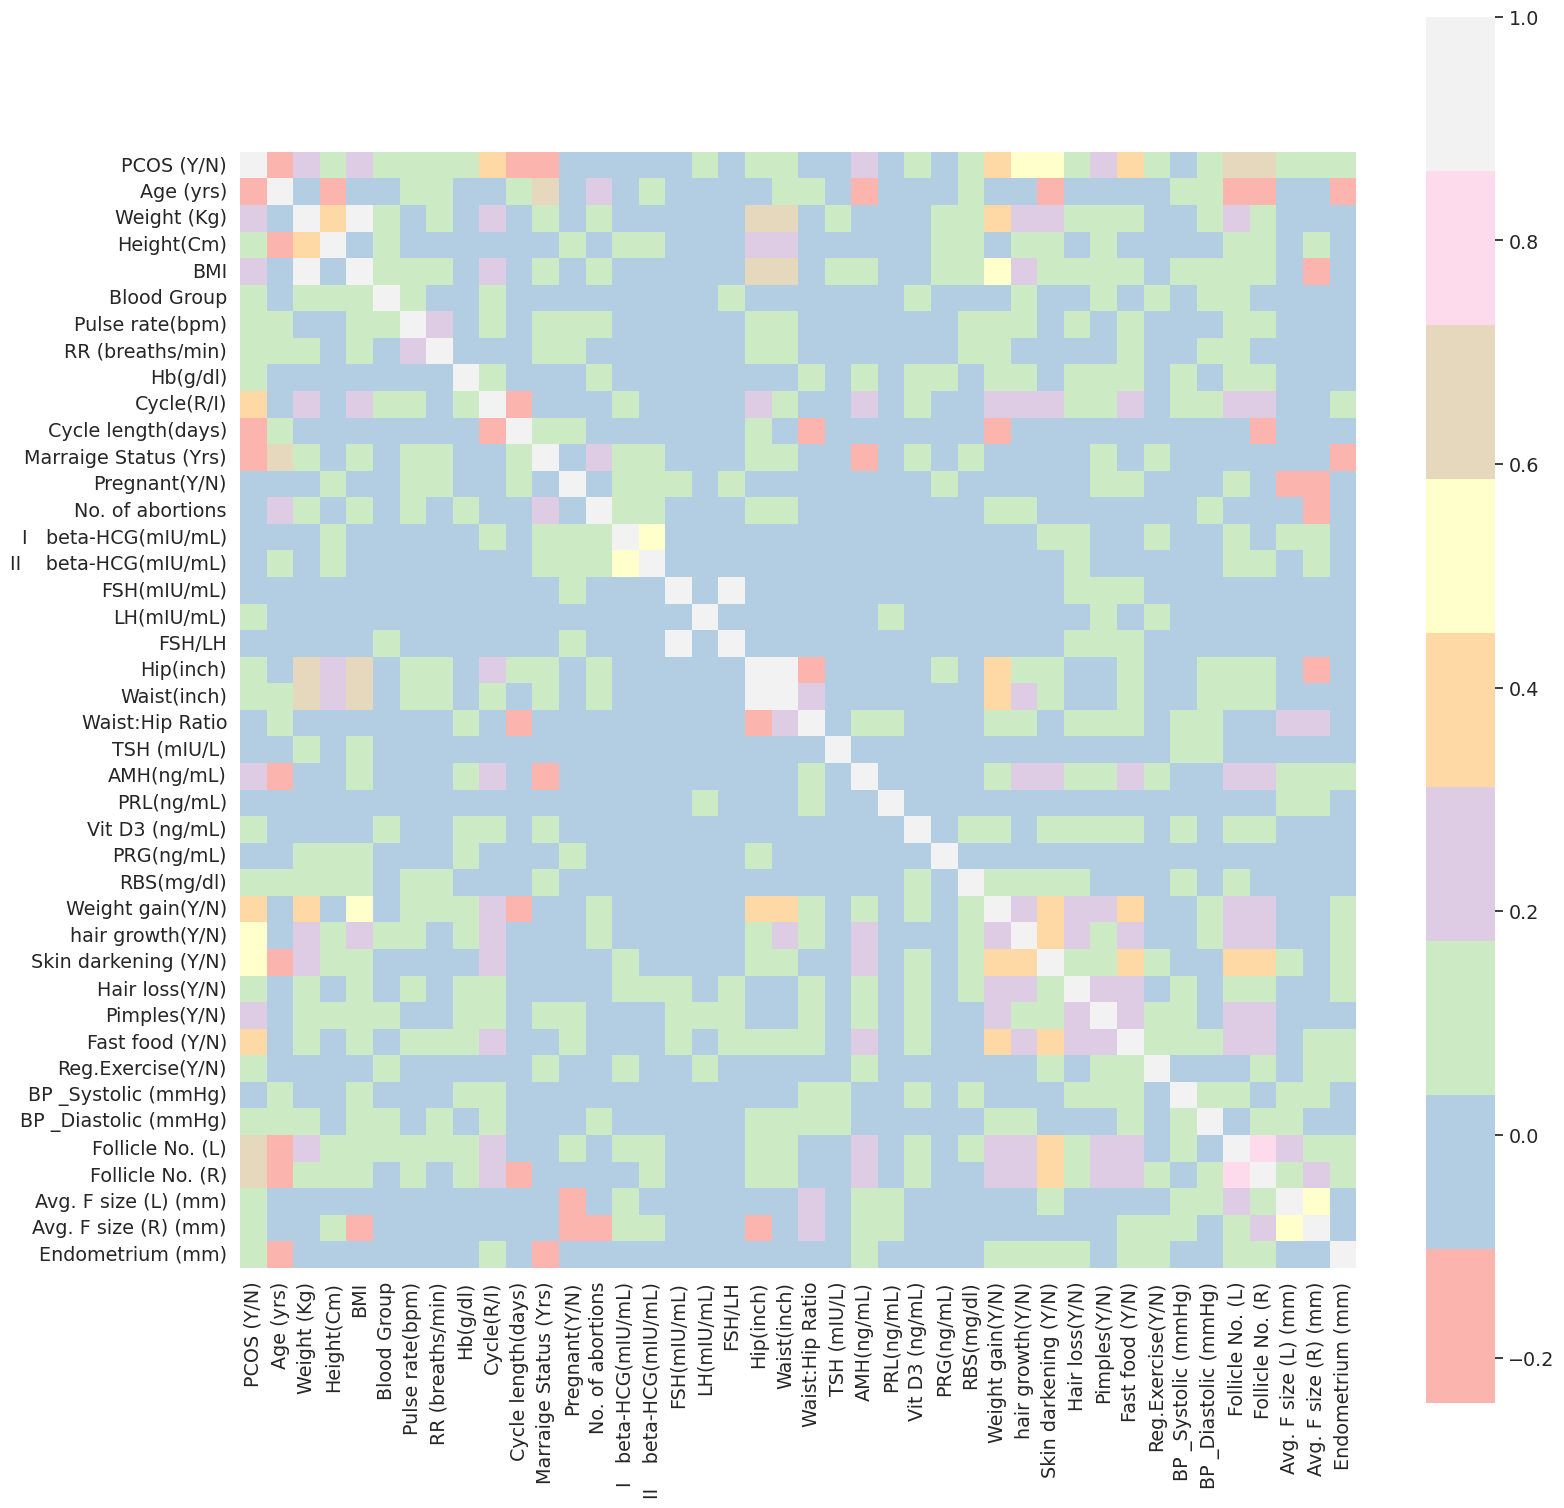

In [25]:
corrmat = df1.corr(numeric_only=True)
plt.subplots(figsize=(18,18))
sns.heatmap(corrmat,cmap="Pastel1", square=True);


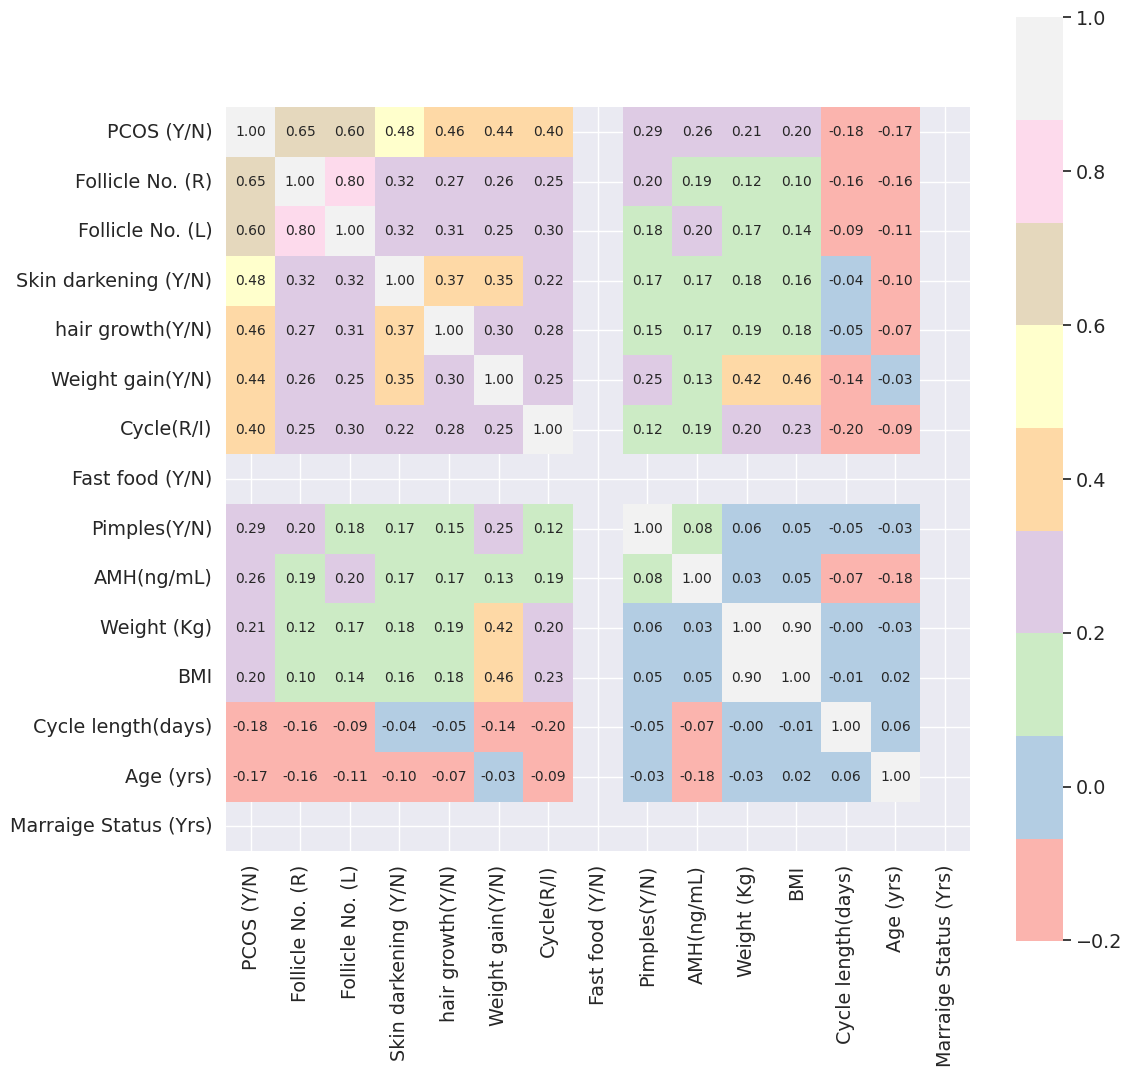

In [26]:
plt.figure(figsize=(12,12))
k = 12 #number of variables with positive for heatmap
l = 3 #number of variables with negative for heatmap
cols_p = corrmat.nlargest(k, "PCOS (Y/N)")["PCOS (Y/N)"].index 
cols_n = corrmat.nsmallest(l, "PCOS (Y/N)")["PCOS (Y/N)"].index
cols = cols_p.append(cols_n) 

cm = np.corrcoef(df1[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True,cmap="Pastel1", annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

feature selection and support vector machine start

In [27]:
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [28]:
features = [
    'Follicle No. (L)', 'Follicle No. (R)',
    'AMH(ng/mL)', 'FSH/LH', 'LH(mIU/mL)',
    'Waist:Hip Ratio', 'BMI', 'Cycle length(days)',
    'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)'
]

# Multi-output targets
targets = [
    'PCOS (Y/N)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Cycle(R/I)'
]

df1['AMH(ng/mL)'] = pd.to_numeric(df1['AMH(ng/mL)'], errors='coerce')
df1 = df1.dropna(subset=features + targets).copy()
X = df1[features]
y = df1[targets]
y = y.apply(lambda col: (col > 0).astype(int))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42,
    stratify=y['PCOS (Y/N)']
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# confirm all binary
print("\nUnique values per target:")
for col in y.columns:
    print(f"  {col}: {sorted(y[col].unique())}")

X_train shape: (432, 10)
y_train shape: (432, 5)

Unique values per target:
  PCOS (Y/N): [np.int64(0), np.int64(1)]
  Weight gain(Y/N): [np.int64(0), np.int64(1)]
  hair growth(Y/N): [np.int64(0), np.int64(1)]
  Skin darkening (Y/N): [np.int64(0), np.int64(1)]
  Cycle(R/I): [np.int64(1)]


In [29]:
print("Unique values per target AFTER split:")
for col in y_train.columns:
    print(f"  {col}: {sorted(y_train[col].unique())}")

Unique values per target AFTER split:
  PCOS (Y/N): [np.int64(0), np.int64(1)]
  Weight gain(Y/N): [np.int64(0), np.int64(1)]
  hair growth(Y/N): [np.int64(0), np.int64(1)]
  Skin darkening (Y/N): [np.int64(0), np.int64(1)]
  Cycle(R/I): [np.int64(1)]


In [33]:
# drop targets that have only one class in training set
valid_targets = [col for col in y_train.columns 
                 if len(y_train[col].unique()) > 1]

print("Valid targets:", valid_targets)

y_train = y_train[valid_targets]
y_test  = y_test[valid_targets]

# update label names to match
LABEL_NAMES = valid_targets

from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain

svc = SVC(kernel='rbf', C=10, gamma='scale',
          probability=True, class_weight='balanced', random_state=42)
# now retrain
svm_model = ClassifierChain(svc, order='random', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred  = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)
print("SVM ready.")

Valid targets: ['PCOS (Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)']


SVM ready.


In [36]:
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain

svc = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_model = ClassifierChain(svc, order='random', random_state=42)
svm_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
svm_pred  = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)
print("SVM ready.")
y_pred=svm_pred
print("Model trained successfully!")

SVM ready.
Model trained successfully!


In [37]:
print("y_test columns:", list(y_test.columns))
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

y_test columns: ['PCOS (Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)']
y_test shape: (109, 4)
y_pred shape: (109, 4)


In [38]:
y_pred = svm_model.predict(X_test)

for i, label in enumerate(y_test.columns):
    report = classification_report(
        y_test.iloc[:, i], y_pred[:, i],
        output_dict=True, zero_division=0
    )
    print(f"\n{label}:")
    print(f"  Accuracy:  {accuracy_score(y_test.iloc[:,i], y_pred[:,i])*100:.1f}%")
    print(f"  Precision: {report['weighted avg']['precision']*100:.1f}%")
    print(f"  Recall:    {report['weighted avg']['recall']*100:.1f}%")
    print(f"  F1:        {report['weighted avg']['f1-score']*100:.1f}%")

cm = confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0])
print("\nConfusion matrix (PCOS):\n", cm)


PCOS (Y/N):
  Accuracy:  79.8%
  Precision: 80.5%
  Recall:    79.8%
  F1:        80.1%

Weight gain(Y/N):
  Accuracy:  68.8%
  Precision: 68.7%
  Recall:    68.8%
  F1:        68.7%

hair growth(Y/N):
  Accuracy:  69.7%
  Precision: 70.6%
  Recall:    69.7%
  F1:        70.1%

Skin darkening (Y/N):
  Accuracy:  67.0%
  Precision: 68.8%
  Recall:    67.0%
  F1:        67.7%

Confusion matrix (PCOS):
 [[60 13]
 [ 9 27]]


In [39]:
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))


--- PCOS (Y/N) ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.85        73
           1       0.68      0.75      0.71        36

    accuracy                           0.80       109
   macro avg       0.77      0.79      0.78       109
weighted avg       0.81      0.80      0.80       109


--- Weight gain(Y/N) ---
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        60
           1       0.66      0.63      0.65        49

    accuracy                           0.69       109
   macro avg       0.68      0.68      0.68       109
weighted avg       0.69      0.69      0.69       109


--- hair growth(Y/N) ---
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        77
           1       0.49      0.53      0.51        32

    accuracy                           0.70       109
   macro avg       0.64      0.65      0.64       109
we

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier , ClassifierChain
rf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Compare on primary target only
print("SVM PCOS Accuracy:", accuracy_score(y_test['PCOS (Y/N)'], y_pred[:, 0]))
print("RF  PCOS Accuracy:", accuracy_score(y_test['PCOS (Y/N)'], rf_pred[:, 0]))

SVM PCOS Accuracy: 0.7981651376146789
RF  PCOS Accuracy: 0.8532110091743119


Plotting 4 labels: ['PCOS (Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)']


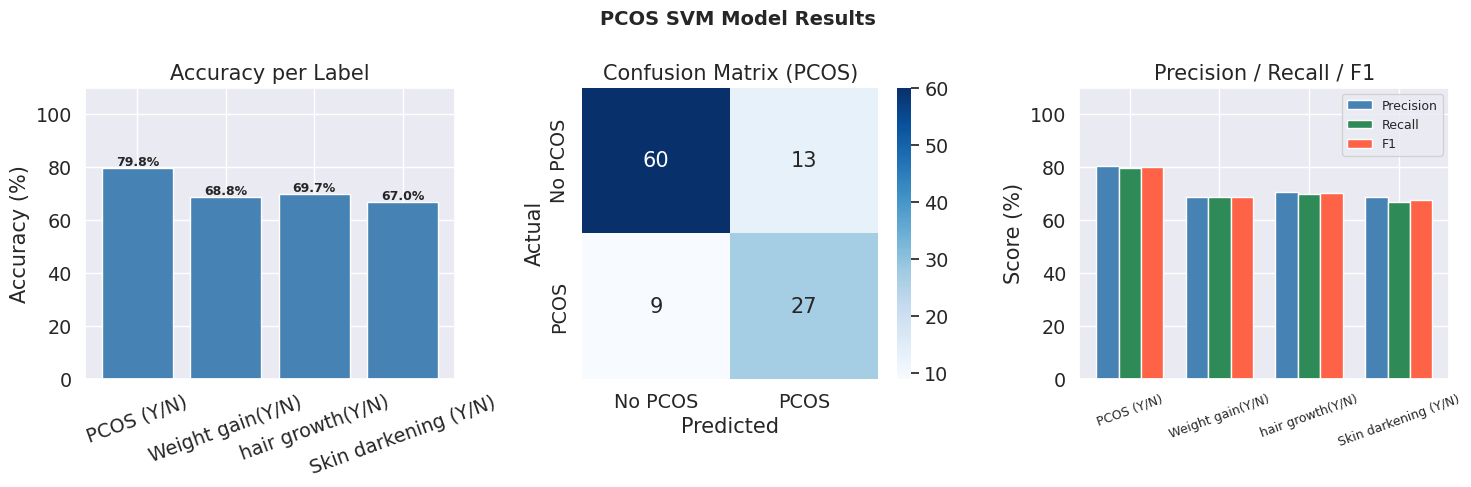

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# derive label count directly from y_test — never hardcode
label_names = list(y_test.columns)
n = len(label_names)

print(f"Plotting {n} labels: {label_names}")

# collect accuracy per label
accs = [accuracy_score(y_test.iloc[:, i], y_pred[:, i]) * 100
        for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PCOS SVM Model Results', fontsize=14, fontweight='bold')

# ── 1. Accuracy bar chart
axes[0].bar(label_names, accs, color='steelblue', edgecolor='white')
axes[0].set_ylim(0, 110)
axes[0].set_title('Accuracy per Label')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── 2. Confusion matrix (PCOS label)
cm = confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No PCOS', 'PCOS'],
            yticklabels=['No PCOS', 'PCOS'])
axes[1].set_title('Confusion Matrix (PCOS)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ── 3. Precision / Recall / F1 grouped bar
metrics = {'Precision': [], 'Recall': [], 'F1': []}
for i in range(n):
    rep = classification_report(y_test.iloc[:, i], y_pred[:, i],
                                output_dict=True, zero_division=0)
    metrics['Precision'].append(rep['weighted avg']['precision'] * 100)
    metrics['Recall'].append(rep['weighted avg']['recall']       * 100)
    metrics['F1'].append(rep['weighted avg']['f1-score']         * 100)

x = np.arange(n)
w = 0.25
axes[2].bar(x - w, metrics['Precision'], width=w, label='Precision', color='steelblue')
axes[2].bar(x,     metrics['Recall'],    width=w, label='Recall',    color='seagreen')
axes[2].bar(x + w, metrics['F1'],        width=w, label='F1',        color='tomato')
axes[2].set_xticks(x)
axes[2].set_xticklabels(label_names, rotation=20, fontsize=9)
axes[2].set_ylim(0, 110)
axes[2].set_title('Precision / Recall / F1')
axes[2].set_ylabel('Score (%)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [44]:
import pickle
pickle.dump(rf, open('pcos_rf.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Saved!")

Saved!


In [45]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

tf.random.set_seed(42)

# dynamically get number of labels
n = y_train.shape[1]
label_cols = list(y_train.columns)
print(f"Building ANN with {n} outputs: {label_cols}")

# build model dynamically based on actual label count
inp = tf.keras.Input(shape=(X_train.shape[1],))
x   = layers.Dense(128, activation='relu')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(64, activation='relu')(x)
x   = layers.Dropout(0.2)(x)
x   = layers.Dense(32, activation='relu')(x)

# create one output head per label dynamically
outputs = [layers.Dense(1, activation='sigmoid', name=f'out_{i}')(x)
           for i in range(n)]

ann_model = Model(inputs=inp, outputs=outputs)

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={f'out_{i}': 'binary_crossentropy' for i in range(n)},
    metrics={f'out_{i}': 'accuracy' for i in range(n)}
)

# pass y as dict matching output names
y_train_dict = {f'out_{i}': y_train.iloc[:, i].values for i in range(n)}

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=0
)

history = ann_model.fit(
    X_train, y_train_dict,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nANN trained — stopped at epoch {len(history.history['loss'])}.")

# predictions
ann_proba_list = ann_model.predict(X_test, verbose=0)
ann_proba      = np.hstack(ann_proba_list)
ann_pred       = (ann_proba >= 0.5).astype(int)
print("ANN ready.")

Building ANN with 4 outputs: ['PCOS (Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)']


E0000 00:00:1778057190.792215    2388 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 3.0168 - out_0_accuracy: 0.6377 - out_0_loss: 0.6827 - out_1_accuracy: 0.6203 - out_1_loss: 0.7993 - out_2_accuracy: 0.6145 - out_2_loss: 0.6838 - out_3_accuracy: 0.4522 - out_3_loss: 0.8421 - val_loss: 2.5932 - val_out_0_accuracy: 0.7471 - val_out_0_loss: 0.6165 - val_out_1_accuracy: 0.6552 - val_out_1_loss: 0.6648 - val_out_2_accuracy: 0.8046 - val_out_2_loss: 0.6594 - val_out_3_accuracy: 0.7471 - val_out_3_loss: 0.6496
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.4446 - out_0_accuracy: 0.7536 - out_0_loss: 0.5290 - out_1_accuracy: 0.6290 - out_1_loss: 0.6620 - out_2_accuracy: 0.6928 - out_2_loss: 0.6048 - out_3_accuracy: 0.6464 - out_3_loss: 0.6490 - val_loss: 2.4688 - val_out_0_accuracy: 0.8506 - val_out_0_loss: 0.5798 - val_out_1_accuracy: 0.6667 - val_out_1_loss: 0.6374 - val_out_2_accuracy: 0.7931 - val_out_2_loss: 0.6428 - val_out_3_accuracy: 0.7356 - val_out_3_loss: 0.6058
Epoch 3/150
11/11 ━━━━━━━━━━━

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.9608 - out_0_accuracy: 0.8551 - out_0_loss: 0.3735 - out_1_accuracy: 0.7710 - out_1_loss: 0.5103 - out_2_accuracy: 0.7681 - out_2_loss: 0.5117 - out_3_accuracy: 0.7188 - out_3_loss: 0.5634 - val_loss: 2.1197 - val_out_0_accuracy: 0.8736 - val_out_0_loss: 0.4456 - val_out_1_accuracy: 0.8276 - val_out_1_loss: 0.5270 - val_out_2_accuracy: 0.8046 - val_out_2_loss: 0.5614 - val_out_3_accuracy: 0.7586 - val_out_3_loss: 0.5755
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9828 - out_0_accuracy: 0.8580 - out_0_loss: 0.3521 - out_1_accuracy: 0.7362 - out_1_loss: 0.5253 - out_2_accuracy: 0.7652 - out_2_loss: 0.5242 - out_3_accuracy: 0.7188 - out_3_loss: 0.5776 - val_loss: 2.0972 - val_out_0_accuracy: 0.8736 - val_out_0_loss: 0.4376 - val_out_1_accuracy: 0.8276 - val_out_1_loss: 0.5196 - val_out_2_accuracy: 0.7931 - val_out_2_loss: 0.5544 - val_out_3_accuracy: 0.7701 - val_out_3_loss: 0.5750
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━

In [46]:
def get_metrics(y_true_df, y_pred_arr):
    accs, precs, recs, f1s = [], [], [], []
    for i in range(y_true_df.shape[1]):   # use actual column count
        rep = classification_report(
            y_true_df.iloc[:, i], y_pred_arr[:, i],
            output_dict=True, zero_division=0
        )
        accs.append(accuracy_score(y_true_df.iloc[:, i], y_pred_arr[:, i]) * 100)
        precs.append(rep['weighted avg']['precision'] * 100)
        recs.append(rep['weighted avg']['recall']     * 100)
        f1s.append( rep['weighted avg']['f1-score']   * 100)
    return accs, precs, recs, f1s

svm_accs, svm_precs, svm_recs, svm_f1s = get_metrics(y_test, svm_pred)
ann_accs, ann_precs, ann_recs, ann_f1s = get_metrics(y_test, ann_pred)

LABEL_NAMES = list(y_test.columns)   # always derive from y_test

print("─" * 50)
print(f"{'Label':<22} {'SVM Acc':>8} {'ANN Acc':>8} {'Winner':>8}")
print("─" * 50)
for i, lbl in enumerate(LABEL_NAMES):
    winner = 'ANN ✓' if ann_accs[i] > svm_accs[i] else 'SVM ✓'
    print(f"{lbl:<22} {svm_accs[i]:>7.1f}% {ann_accs[i]:>7.1f}% {winner:>8}")
print("─" * 50)
print(f"{'Average':<22} {np.mean(svm_accs):>7.1f}% {np.mean(ann_accs):>7.1f}%")

──────────────────────────────────────────────────
Label                   SVM Acc  ANN Acc   Winner
──────────────────────────────────────────────────
PCOS (Y/N)                79.8%    83.5%    ANN ✓
Weight gain(Y/N)          68.8%    67.9%    SVM ✓
hair growth(Y/N)          69.7%    77.1%    ANN ✓
Skin darkening (Y/N)      67.0%    72.5%    ANN ✓
──────────────────────────────────────────────────
Average                   71.3%    75.2%


In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
print("Training Gradient Boosting ClassifierChain...")
 
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_chain = ClassifierChain(gb, order='random', random_state=42)
gb_chain.fit(X_train, y_train)
gb_pred  = gb_chain.predict(X_test)
gb_proba = gb_chain.predict_proba(X_test)
print("Gradient Boosting trained.\n")


Training Gradient Boosting ClassifierChain...
Gradient Boosting trained.



In [48]:
def get_metrics(y_true_df, y_pred_arr):
    accs, precs, recs, f1s = [], [], [], []
    for i in range(y_true_df.shape[1]):
        rep = classification_report(
            y_true_df.iloc[:, i], y_pred_arr[:, i],
            output_dict=True, zero_division=0
        )
        accs.append(accuracy_score(y_true_df.iloc[:, i], y_pred_arr[:, i]) * 100)
        precs.append(rep['weighted avg']['precision'] * 100)
        recs.append(rep['weighted avg']['recall']     * 100)
        f1s.append( rep['weighted avg']['f1-score']   * 100)
    return accs, precs, recs, f1s
 
svm_accs, svm_precs, svm_recs, svm_f1s = get_metrics(y_test, svm_pred)
ann_accs, ann_precs, ann_recs, ann_f1s = get_metrics(y_test, ann_pred)
gb_accs,  gb_precs,  gb_recs,  gb_f1s  = get_metrics(y_test, gb_pred)
 
LABEL_NAMES = list(y_test.columns)
n           = len(LABEL_NAMES)
short       = [l[:8] for l in LABEL_NAMES]
 
COLORS = {
    'SVM': '#6C63FF',
    'ANN': '#3ecfa0',
    'GB':  '#f07070'
}

In [49]:
print("═" * 62)
print(f"  {'Label':<22} {'SVM':>8} {'ANN':>8} {'GB':>8} {'Winner':>8}")
print("═" * 62)
for i, lbl in enumerate(LABEL_NAMES):
    scores = {'SVM': svm_accs[i], 'ANN': ann_accs[i], 'GB': gb_accs[i]}
    winner = max(scores, key=scores.get)
    print(f"  {lbl:<22} {svm_accs[i]:>7.1f}% {ann_accs[i]:>7.1f}% {gb_accs[i]:>7.1f}%  {winner} ✓")
print("─" * 62)
print(f"  {'Average':<22} {np.mean(svm_accs):>7.1f}% {np.mean(ann_accs):>7.1f}% {np.mean(gb_accs):>7.1f}%")
 
overall = {'SVM': np.mean(svm_accs), 'ANN': np.mean(ann_accs), 'GB': np.mean(gb_accs)}
overall_winner = max(overall, key=overall.get)
print(f"\n  Overall winner: {overall_winner} ✓")
print("═" * 62)
 

══════════════════════════════════════════════════════════════
  Label                       SVM      ANN       GB   Winner
══════════════════════════════════════════════════════════════
  PCOS (Y/N)                79.8%    83.5%    83.5%  ANN ✓
  Weight gain(Y/N)          68.8%    67.9%    63.3%  SVM ✓
  hair growth(Y/N)          69.7%    77.1%    69.7%  ANN ✓
  Skin darkening (Y/N)      67.0%    72.5%    66.1%  ANN ✓
──────────────────────────────────────────────────────────────
  Average                   71.3%    75.2%    70.6%

  Overall winner: ANN ✓
══════════════════════════════════════════════════════════════


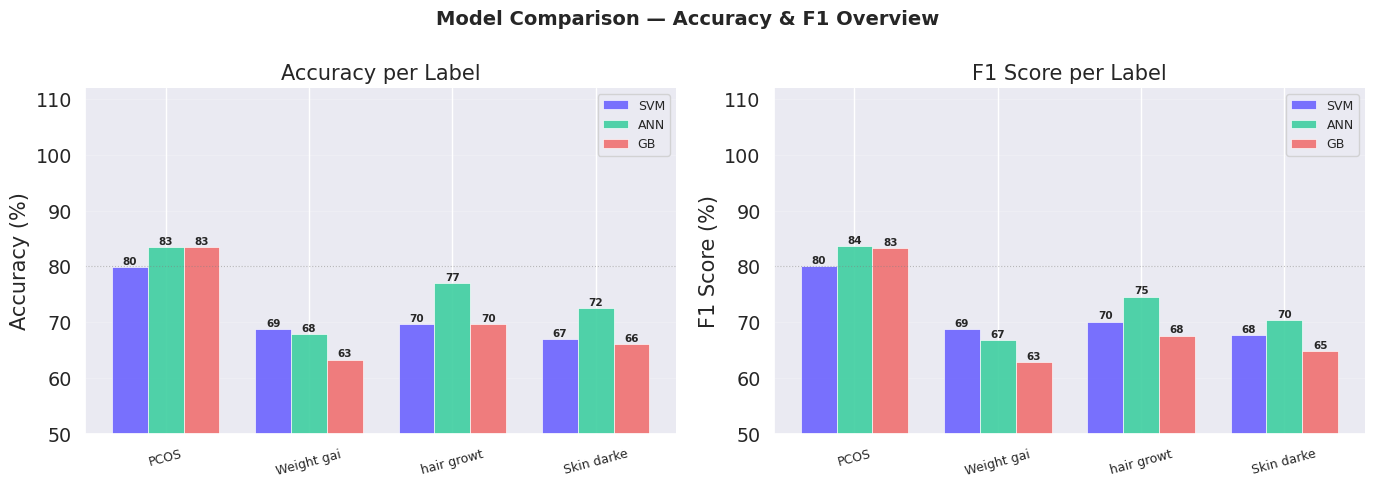

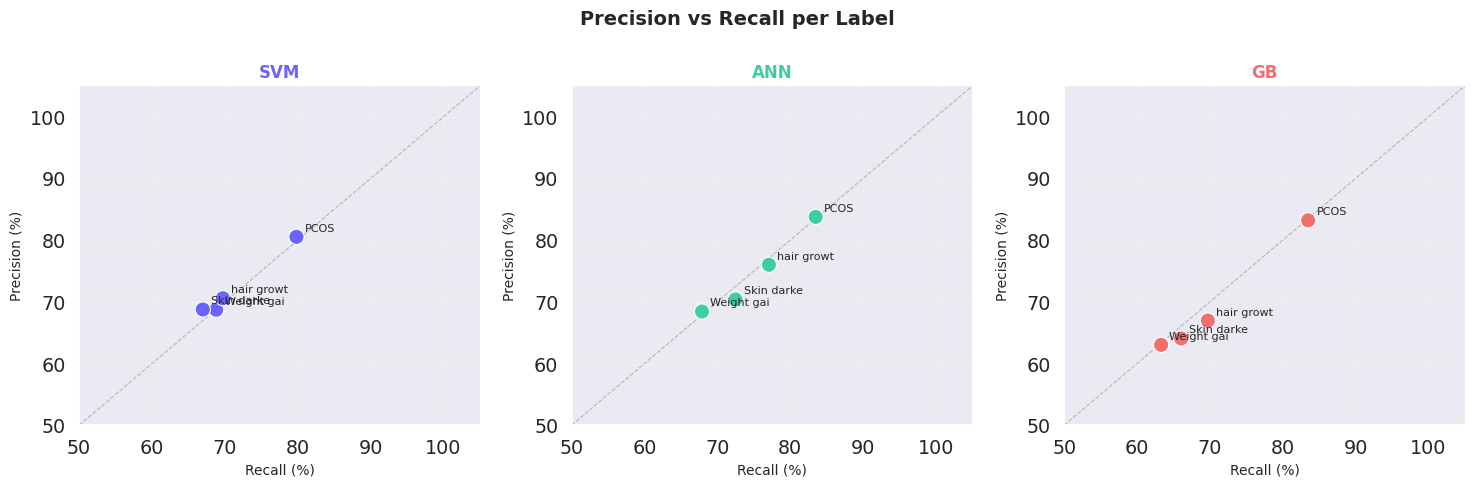

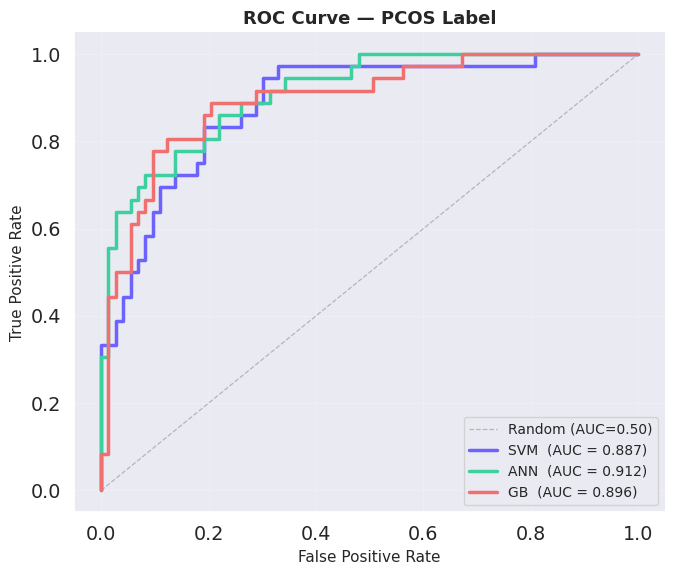

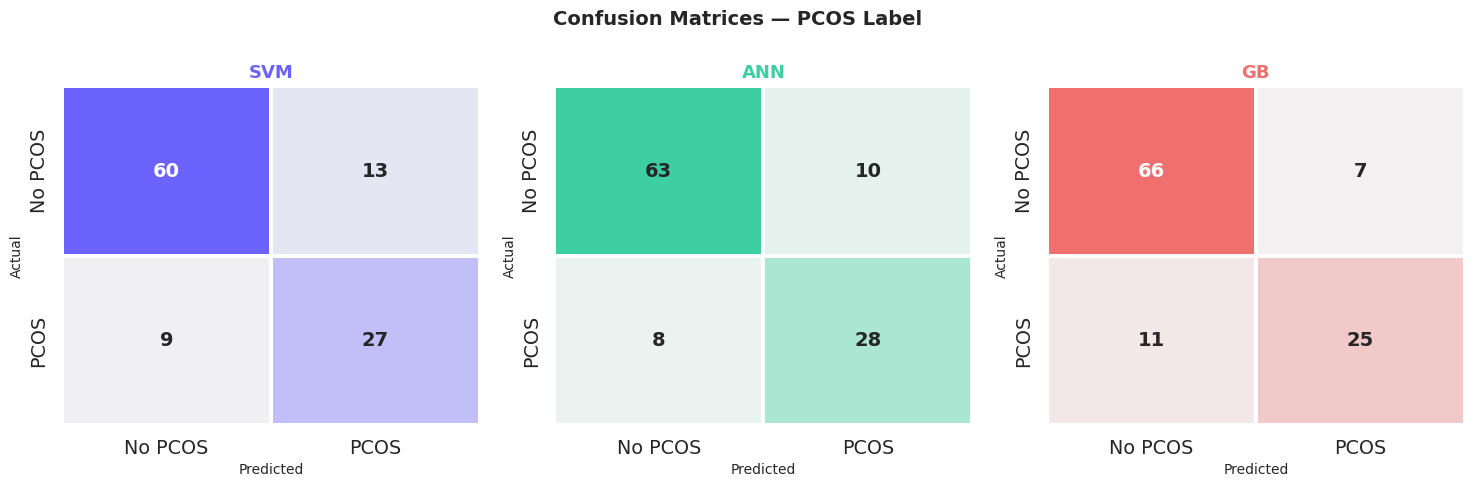

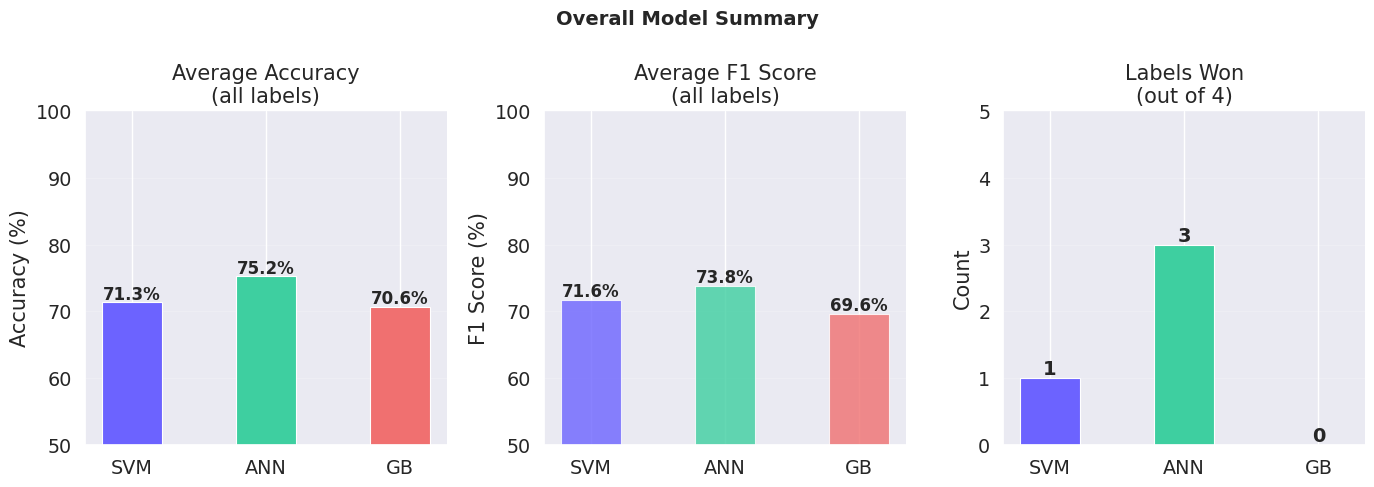


✓ All 5 figures saved.

  Average Accuracy → SVM: 71.3%  ANN: 75.2%  GB: 70.6%
  Average F1 Score → SVM: 71.6%  ANN: 73.8%  GB: 69.6%
  Labels won       → SVM: 1  ANN: 3  GB: 0


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# ── colors
C = {'SVM': '#6C63FF', 'ANN': '#3ecfa0', 'GB': '#f07070'}

LABEL_NAMES = list(y_test.columns)
n     = len(LABEL_NAMES)
short = [l.replace('(Y/N)', '').replace('(R/I)', '').strip()[:10]
         for l in LABEL_NAMES]

# ── collect all metrics
def get_metrics(y_true_df, y_pred_arr):
    accs, precs, recs, f1s = [], [], [], []
    for i in range(y_true_df.shape[1]):
        rep = classification_report(
            y_true_df.iloc[:, i], y_pred_arr[:, i],
            output_dict=True, zero_division=0
        )
        accs.append(accuracy_score(y_true_df.iloc[:, i], y_pred_arr[:, i]) * 100)
        precs.append(rep['weighted avg']['precision'] * 100)
        recs.append(rep['weighted avg']['recall']     * 100)
        f1s.append( rep['weighted avg']['f1-score']   * 100)
    return accs, precs, recs, f1s

svm_accs, svm_precs, svm_recs, svm_f1s = get_metrics(y_test, svm_pred)
ann_accs, ann_precs, ann_recs, ann_f1s = get_metrics(y_test, ann_pred)
gb_accs,  gb_precs,  gb_recs,  gb_f1s  = get_metrics(y_test, gb_pred)

models      = ['SVM', 'ANN', 'GB']
all_accs    = [svm_accs,  ann_accs,  gb_accs]
all_precs   = [svm_precs, ann_precs, gb_precs]
all_recs    = [svm_recs,  ann_recs,  gb_recs]
all_f1s     = [svm_f1s,   ann_f1s,   gb_f1s]
all_preds   = [svm_pred,  ann_pred,  gb_pred]
all_probas  = [svm_proba, ann_proba, gb_proba]
avg_accs    = [np.mean(a) for a in all_accs]
avg_f1s     = [np.mean(f) for f in all_f1s]

# ════════════════════════════════════════════════════════
# FIGURE 1 — ACCURACY & F1 OVERVIEW
# ════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Model Comparison — Accuracy & F1 Overview',
              fontsize=14, fontweight='bold')

x = np.arange(n)
w = 0.25

# grouped accuracy
ax = axes[0]
for j, (model, accs) in enumerate(zip(models, all_accs)):
    bars = ax.bar(x + (j - 1) * w, accs, width=w,
                  color=C[model], label=model,
                  alpha=0.9, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short, rotation=15, fontsize=9)
ax.set_ylim(50, 112)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy per Label')
ax.legend(fontsize=9)
ax.axhline(80, color='gray', lw=0.8, linestyle=':', alpha=0.5)
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# grouped F1
ax = axes[1]
for j, (model, f1s) in enumerate(zip(models, all_f1s)):
    bars = ax.bar(x + (j - 1) * w, f1s, width=w,
                  color=C[model], label=model,
                  alpha=0.9, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short, rotation=15, fontsize=9)
ax.set_ylim(50, 112)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score per Label')
ax.legend(fontsize=9)
ax.axhline(80, color='gray', lw=0.8, linestyle=':', alpha=0.5)
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# FIGURE 2 — PRECISION vs RECALL SCATTER
# ════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('Precision vs Recall per Label',
              fontsize=14, fontweight='bold')

for ax, model, precs, recs in zip(
    axes2, models, all_precs, all_recs
):
    scatter = ax.scatter(recs, precs,
                          c=[C[model]] * n,
                          s=120, zorder=3,
                          edgecolors='white', linewidths=0.8)
    for i, lbl in enumerate(short):
        ax.annotate(lbl, (recs[i], precs[i]),
                    textcoords='offset points',
                    xytext=(6, 4), fontsize=8)
    ax.plot([50, 105], [50, 105], '--',
             color='gray', lw=0.8, alpha=0.5)
    ax.set_xlim(50, 105)
    ax.set_ylim(50, 105)
    ax.set_xlabel('Recall (%)', fontsize=10)
    ax.set_ylabel('Precision (%)', fontsize=10)
    ax.set_title(f'{model}', fontsize=12,
                  fontweight='bold', color=C[model])
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# FIGURE 3 — ROC CURVES (PCOS label)
# ════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.plot([0, 1], [0, 1], '--', color='gray', lw=0.9,
          alpha=0.5, label='Random (AUC=0.50)')

for model, proba in zip(models, all_probas):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, 0], proba[:, 0])
    roc_auc     = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color=C[model], lw=2.5,
              label=f'{model}  (AUC = {roc_auc:.3f})')

ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curve — PCOS Label', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.2)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# FIGURE 4 — CONFUSION MATRICES (PCOS label)
# ════════════════════════════════════════════════════════
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 5))
fig4.suptitle('Confusion Matrices — PCOS Label',
              fontsize=14, fontweight='bold')

for ax, model, pred in zip(axes4, models, all_preds):
    cm = confusion_matrix(y_test.iloc[:, 0], pred[:, 0])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(C[model], as_cmap=True),
                xticklabels=['No PCOS', 'PCOS'],
                yticklabels=['No PCOS', 'PCOS'],
                linewidths=1.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'},
                cbar=False)
    ax.set_title(model, fontsize=13, fontweight='bold', color=C[model])
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# FIGURE 5 — OVERALL SUMMARY DASHBOARD
# ════════════════════════════════════════════════════════
fig5, axes5 = plt.subplots(1, 3, figsize=(14, 5))
fig5.suptitle('Overall Model Summary', fontsize=14, fontweight='bold')

# avg accuracy bar
ax = axes5[0]
bars = ax.bar(models, avg_accs,
               color=[C[m] for m in models],
               width=0.45, edgecolor='white', linewidth=0.8)
ax.set_ylim(50, 100)
ax.set_title('Average Accuracy\n(all labels)')
ax.set_ylabel('Accuracy (%)')
for bar, val in zip(bars, avg_accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# avg F1 bar
ax = axes5[1]
bars = ax.bar(models, avg_f1s,
               color=[C[m] for m in models],
               width=0.45, edgecolor='white', linewidth=0.8,
               alpha=0.8)
ax.set_ylim(50, 100)
ax.set_title('Average F1 Score\n(all labels)')
ax.set_ylabel('F1 Score (%)')
for bar, val in zip(bars, avg_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# wins per model (how many labels each model wins)
ax = axes5[2]
wins = {m: 0 for m in models}
for i in range(n):
    scores = {
        'SVM': svm_accs[i],
        'ANN': ann_accs[i],
        'GB':  gb_accs[i]
    }
    wins[max(scores, key=scores.get)] += 1

bars = ax.bar(list(wins.keys()), list(wins.values()),
               color=[C[m] for m in wins.keys()],
               width=0.45, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, n + 1)
ax.set_title(f'Labels Won\n(out of {n})')
ax.set_ylabel('Count')
for bar, val in zip(bars, wins.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            str(val), ha='center', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All 5 figures saved.")
print(f"\n  Average Accuracy → SVM: {avg_accs[0]:.1f}%  "
      f"ANN: {avg_accs[1]:.1f}%  GB: {avg_accs[2]:.1f}%")
print(f"  Average F1 Score → SVM: {avg_f1s[0]:.1f}%  "
      f"ANN: {avg_f1s[1]:.1f}%  GB: {avg_f1s[2]:.1f}%")
print(f"  Labels won       → SVM: {wins['SVM']}  "
      f"ANN: {wins['ANN']}  GB: {wins['GB']}")